<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2010/%5BLab_10_%5D_Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# !pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


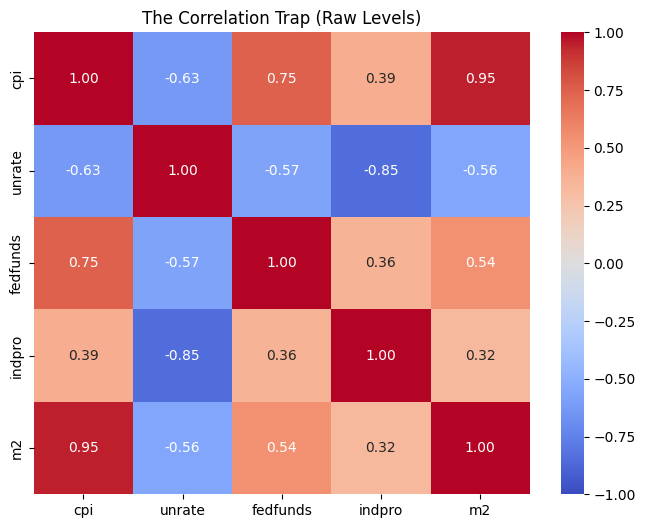

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [10]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))
]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


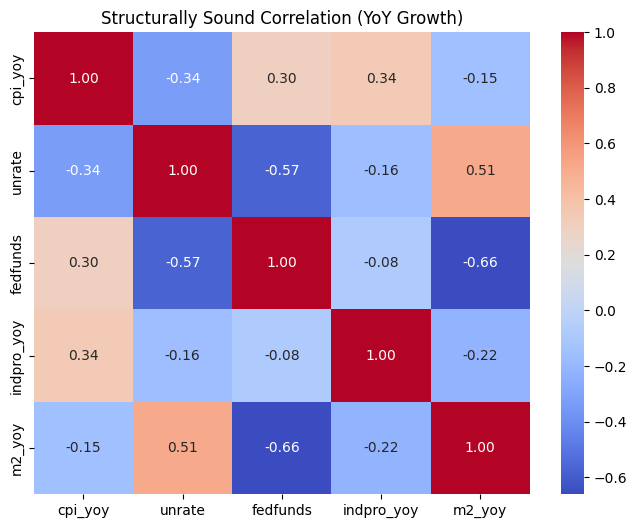

In [4]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

Step 5: Causal Graphing (DAG Construction)
Before arbitrarily dropping variables or accepting transformations, you must map your causal assumptions using a Directed Acyclic Graph (DAG).

Are M2 and CPI directly causal, or are they both descendants of a common unobserved confounder, such as "Expansionary Macro Policy" (The Fork)? Transforming the data fixes the math, but the DAG fixes the logic.

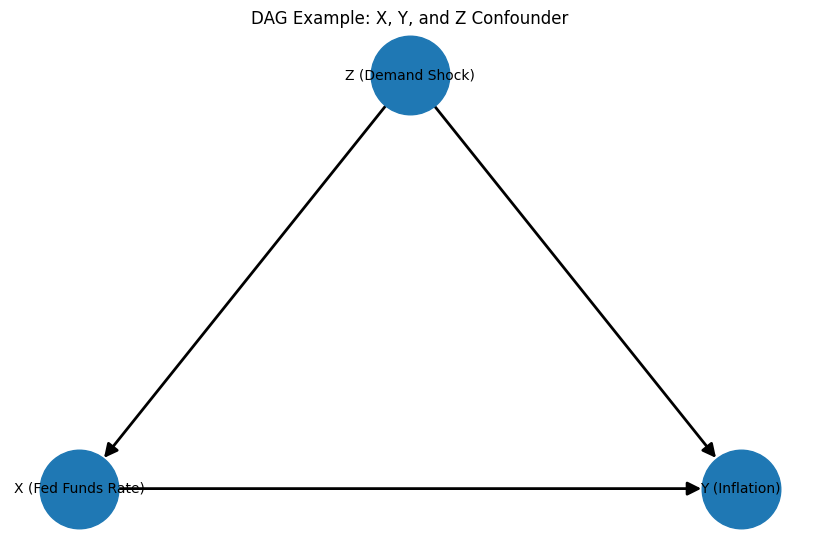

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

In [7]:
# 3. AI-Assisted Expansion: Scaling to Interactive Dashboards


import numpy as np
import plotly.graph_objects as go
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. FETCH & PREPARE DATA
# ─────────────────────────────────────────────
start, end = "2010-01-01", "2024-01-01"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE":   "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO":   "indpro",
    "M2SL":     "m2",
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()

# Apply YoY % growth to the three trending/non-stationary variables.
# Unemployment and Fed Funds are already expressed as rates, so we keep
# them in levels even in the "transformed" view.
df_t = df.copy()
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)
df_t = df_t.dropna()

# ─────────────────────────────────────────────
# 2. BUILD CORRELATION MATRICES
# ─────────────────────────────────────────────
# Raw levels – all five variables in their original units
raw_cols = ["cpi", "unrate", "fedfunds", "indpro", "m2"]
corr_raw = df[raw_cols].corr()

# YoY view – swap the three trending vars for their growth-rate versions
yoy_cols = ["cpi_yoy", "unrate", "fedfunds", "indpro_yoy", "m2_yoy"]
corr_yoy = df_t[yoy_cols].corr()

# Human-readable axis labels for both views
labels_raw = ["CPI", "Unemployment", "Fed Funds", "Ind. Production", "M2"]
labels_yoy = ["CPI (YoY%)", "Unemployment", "Fed Funds", "Ind. Prod. (YoY%)", "M2 (YoY%)"]

# ─────────────────────────────────────────────
# 3. HELPER – build annotation text matrix
# ─────────────────────────────────────────────
def make_annotations(corr_df, labels):
    """
    Return a list-of-lists of formatted correlation strings.
    Plotly's Heatmap 'text' parameter accepts this structure
    and renders each cell's value via 'texttemplate'.
    """
    return [[f"{corr_df.iloc[i, j]:.2f}" for j in range(len(labels))]
            for i in range(len(labels))]

text_raw = make_annotations(corr_raw, labels_raw)
text_yoy = make_annotations(corr_yoy, labels_yoy)

# ─────────────────────────────────────────────
# 4. CREATE THE FIGURE WITH TWO TRACES
# ─────────────────────────────────────────────
# Both heatmap traces are added to the figure upfront.
# Only one is visible at a time; the dropdown switches visibility.
# This is the core architecture: pre-render everything, then toggle.

fig = go.Figure()

# ── Trace 0: Raw levels ──────────────────────
fig.add_trace(go.Heatmap(
    z=corr_raw.values,          # numeric correlation matrix (2-D array)
    x=labels_raw,               # column labels
    y=labels_raw,               # row labels
    text=text_raw,              # annotation strings
    texttemplate="%{text}",     # render the text string in each cell
    textfont=dict(size=13, color="black"),
    colorscale="RdBu",          # red = positive, blue = negative
    zmin=-1, zmax=1,            # fix scale so both views are comparable
    reversescale=True,          # red → positive (conventional for corr)
    colorbar=dict(title="r", tickvals=[-1, -0.5, 0, 0.5, 1]),
    visible=True,               # shown by default
    name="Raw Levels",
))

# ── Trace 1: YoY growth rates ────────────────
fig.add_trace(go.Heatmap(
    z=corr_yoy.values,
    x=labels_yoy,
    y=labels_yoy,
    text=text_yoy,
    texttemplate="%{text}",
    textfont=dict(size=13, color="black"),
    colorscale="RdBu",
    zmin=-1, zmax=1,
    reversescale=True,
    colorbar=dict(title="r", tickvals=[-1, -0.5, 0, 0.5, 1]),
    visible=False,              # hidden until selected from dropdown
    name="YoY Growth",
))

# ─────────────────────────────────────────────
# 5. DROPDOWN via updatemenus
# ─────────────────────────────────────────────
# Each button passes an 'args' list to Plotly's relayout/restyle engine.
# 'restyle' mutates trace-level properties; 'update' combines restyle +
# relayout (layout-level). Here we use 'update' so we can simultaneously
# toggle trace visibility AND change the title text.
#
# args[0] = dict of TRACE properties  → {'visible': [True, False]}
# args[1] = dict of LAYOUT properties → {'title.text': '...'}
#
# The two-element list in 'visible' maps 1-to-1 with the trace list:
#   [True, False]  → show trace 0, hide trace 1
#   [False, True]  → hide trace 0, show trace 1

fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01, y=1.18,         # position: top-left above chart
        showactive=True,
        bgcolor="#f0f4f8",
        bordercolor="#2563eb",
        font=dict(size=13),
        buttons=[
            dict(
                label="📊 Raw Levels",
                method="update",          # restyle + relayout combined
                args=[
                    {"visible": [True, False]},   # trace visibility mask
                    {"title.text": (
                        "<b>Correlation Matrix — Raw Levels</b>"
                        "<br><sup>⚠️ Spurious trend-driven correlations</sup>"
                    )},
                ],
            ),
            dict(
                label="📈 YoY Growth Rates",
                method="update",
                args=[
                    {"visible": [False, True]},   # flip visibility
                    {"title.text": (
                        "<b>Correlation Matrix — YoY Growth Rates</b>"
                        "<br><sup>✅ Trend removed — structurally meaningful correlations</sup>"
                    )},
                ],
            ),
        ],
    )],
    title=dict(
        text=(
            "<b>Correlation Matrix — Raw Levels</b>"
            "<br><sup>⚠️ Spurious trend-driven correlations</sup>"
        ),
        x=0.5, xanchor="center",
        font=dict(size=16),
    ),
    width=700, height=620,
    margin=dict(t=120, l=120, r=40, b=40),
    paper_bgcolor="#ffffff",
    plot_bgcolor="#f8fafc",
    font=dict(family="Segoe UI, Arial", size=12),
)

fig.show()